In [20]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam


In [21]:
dataset_dir = "C:\\Users\\SURESH\\Downloads\\PetImages"

In [22]:
datagen = ImageDataGenerator(rescale=1.0/255, validation_split=0.2)  
# 20% images will be used for testing

train_data = datagen.flow_from_directory(
    dataset_dir,
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary',   # since cats vs dogs (2 classes)
    subset='training'
)

test_data = datagen.flow_from_directory(
    dataset_dir,
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)


Found 20000 images belonging to 2 classes.
Found 4998 images belonging to 2 classes.


In [23]:
model = Sequential([
    Flatten(input_shape=(64, 64, 3)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')  # binary classification
])

model.compile(optimizer=Adam(),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_1 (Flatten)         (None, 12288)             0         
                                                                 
 dense_3 (Dense)             (None, 128)               1572992   
                                                                 
 dense_4 (Dense)             (None, 64)                8256      
                                                                 
 dense_5 (Dense)             (None, 1)                 65        
                                                                 
Total params: 1,581,313
Trainable params: 1,581,313
Non-trainable params: 0
_________________________________________________________________


In [24]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

Epoch 1/10
625/625 [==============================] - 91s 142ms/step - loss: 0.7349 - accuracy: 0.5663 - val_loss: 0.6624 - val_accuracy: 0.5982
Epoch 2/10
625/625 [==============================] - 78s 125ms/step - loss: 0.6674 - accuracy: 0.5943 - val_loss: 0.6624 - val_accuracy: 0.5958
Epoch 3/10
625/625 [==============================] - 75s 121ms/step - loss: 0.6584 - accuracy: 0.6062 - val_loss: 0.6654 - val_accuracy: 0.5876
Epoch 4/10
625/625 [==============================] - 81s 130ms/step - loss: 0.6545 - accuracy: 0.6101 - val_loss: 0.6569 - val_accuracy: 0.6022
Epoch 5/10
625/625 [==============================] - 79s 126ms/step - loss: 0.6575 - accuracy: 0.6095 - val_loss: 0.6808 - val_accuracy: 0.5606
Epoch 6/10
625/625 [==============================] - 77s 124ms/step - loss: 0.6568 - accuracy: 0.6083 - val_loss: 0.6551 - val_accuracy: 0.6122
Epoch 7/10
625/625 [==============================] - 79s 127ms/step - loss: 0.6505 - accuracy: 0.6226 - val_loss: 0.6679 - val_ac

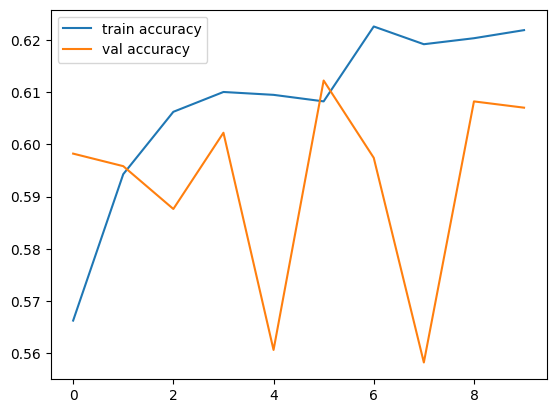

In [25]:
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.show()


In [26]:
loss, acc = model.evaluate(test_data)
print(f"Test Accuracy: {acc*100:.2f}%")


157/157 [==============================] - 15s 94ms/step - loss: 0.6591 - accuracy: 0.6070
Test Accuracy: 60.70%


1/1 [==============================] - 0s 103ms/step


C:\Users\SURESH\AppData\Local\Temp\ipykernel_5588\15769743.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(f"True: {int(labels[i])}, Predicted: {int(predictions[i] > 0.5)}")


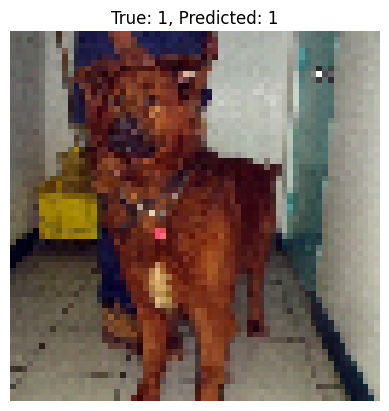

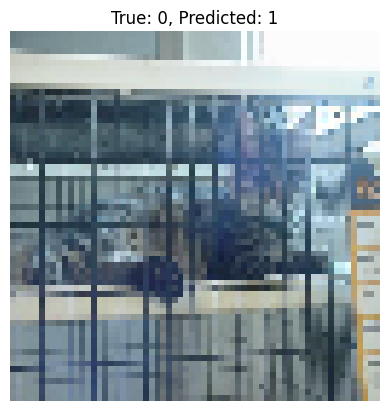

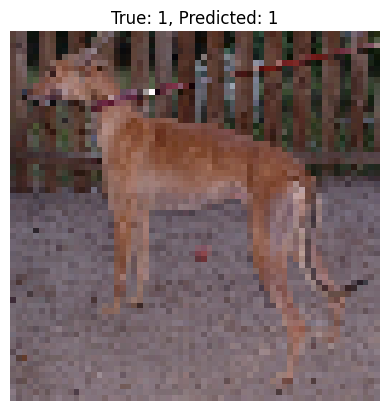

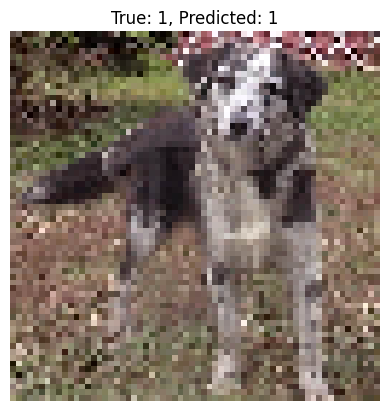

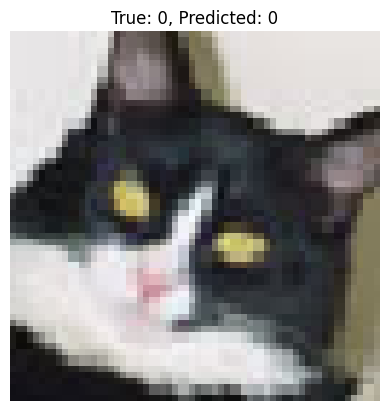

In [27]:
images, labels = next(test_data)
predictions = model.predict(images[:5])

for i in range(5):
    plt.imshow(images[i])
    plt.title(f"True: {int(labels[i])}, Predicted: {int(predictions[i] > 0.5)}")
    plt.axis('off')
    plt.show()
